# Comparison ARPEGE-HR ERA5

In [3]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import (
    swot_dir,
    drifters_dir,
    get_proj,
    lonlat2xy,
    zarr_dir,
    surface_drifters,
    depth_drifters,
    depth_100,
    depth_50,
    images_dir,
    U2,
    err_acc,
)
from diagnosis import (
    put_fig_letter,
    update_dict,
    dataset_coloc_combs,
    dataset_coloc_combs,
    prepared_drifters,
    prepared_wd,
    prepared_alti,
    compute_variance_groupby,
    compute_variance,
)

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

from diagnosis import synthetic_figure
from cstes import U2, c0

In [4]:
dt = 3
distance_to_coast_max = 20e3
alti_product_key = "swot2km"

In [14]:
# SURFACE
base_dic = dict(
    dt="12h",
    drifter_preprocess="",
    drifter_preprocess_param="",
    alti_product_key="swot2km",
    alti_diff_method="fromduacsv",
    alti_diff_method_param="",
    ggd_var="fromduacsv",
    wd_product_key="era5",
    wd_model="rio",
    wd_depth="0",
)

comb_list = [base_dic,
    update_dict(base_dic, {"wd_product_key": "arpege"}),
]

l = [
    "era5",
    "arpege",
]

ds0 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds0["comb"] = ds0["id_comb"]
ds0["id_comb"] = ("id_comb", l)
distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
ds0["distance_to_coast"] = ("row_number", distance_to_coast.values)


# 15m
base_dic = dict(
    dt="12h",
    drifter_preprocess="",
    drifter_preprocess_param="",
    alti_product_key="swot2km",
    alti_diff_method="fromduacsv",
    alti_diff_method_param="",
    ggd_var="fromduacsv",
    wd_product_key="era5",
    wd_model="rio",
    wd_depth="15",
)

comb_list = [base_dic,
    update_dict(base_dic, {"wd_product_key": "arpege"}),
]

l = [
    "era5",
    "arpege",
]

ds15 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds15["comb"] = ds15["id_comb"]
ds15["id_comb"] = ("id_comb", l)
distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
ds15["distance_to_coast"] = ("row_number", distance_to_coast.values)



12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__arpege_rio0
Identified SWOT and drifter outliers have been removed
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio15
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__arpege_rio15
Identified SWOT and drifter outliers have been removed


In [15]:
ds0 = ds0.where(
    (ds0.drifter_type != "SPOTTER") & (ds0.drifter_type != "MELODI"), drop=True
)

DS = xr.concat(
    [ds0.where(ds0.depth == 0, drop=True), ds15.where(ds15.depth == 15, drop=True)],
    dim="row_number",
)
DS = DS.where(DS.time_to_swot / pd.Timedelta("1h") < dt).dropna("row_number")
# DS = DS.where((abs(DS.ggde)<1e-4) & (abs(DS.ggdn)<1e-4), drop=True)
DS = DS.where(DS.distance_to_coast > distance_to_coast_max, drop=True)


ds = compute_variance(DS, compute_error="centrallimit") / U2

# Closure figs
df = ds.to_dataframe()
df = (
    df.reset_index()
    .rename(columns={"id_comb": "Altimetric product"})
    .set_index("Altimetric product")
)

2115


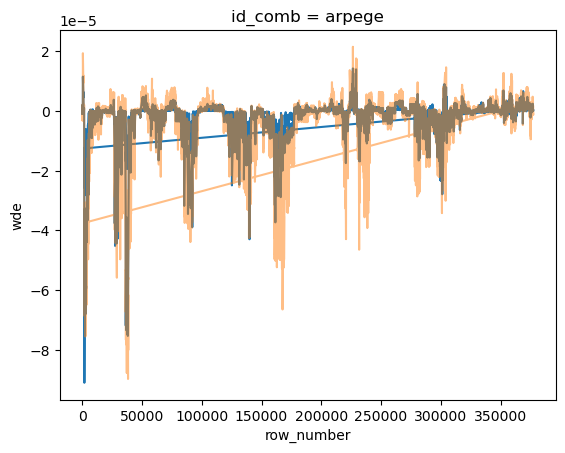

In [17]:
DS.wde.sel(id_comb='era5').plot()
DS.wde.sel(id_comb='arpege').plot(alpha=0.5)

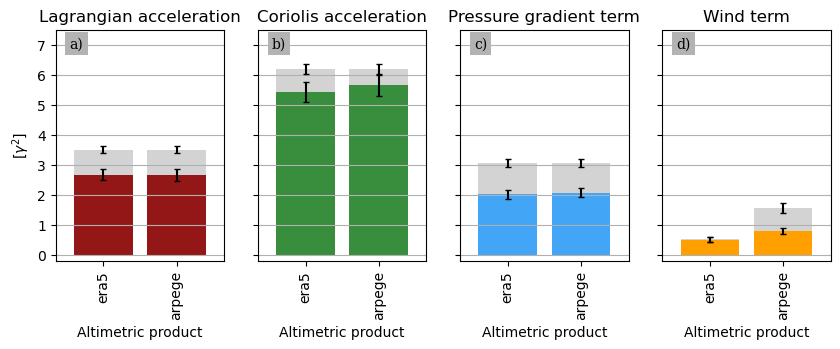

In [22]:
vars = ["acc", "cor", "ggd", "wd"]
title = {
    "acc": "Lagrangian acceleration",
    "cor": "Coriolis acceleration",
    "ggd": "Pressure gradient term",
    "wd": "Wind term",
}
plt.rcParams["axes.edgecolor"] = "k"

kwargs = dict(width=0.8, capsize=2)
fig, axs = plt.subplots(1, 4, figsize=(10, 3), frameon=False, sharex=True, sharey=True)
axs = axs.flatten()
for j in range(len(vars)):
    ax = axs[j]
    df["E_" + vars[j]].plot.bar(
        ax=ax,
        color="lightgrey",
        bottom=df["B_" + vars[j]],
        yerr=df["er__E_" + vars[j]],
        **kwargs
    )
    df["B_" + vars[j]].plot.bar(
        ax=ax, color=c0[vars[j]], yerr=df["er__B_" + vars[j]], **kwargs
    )
    ax.grid(axis="y")
    ax.set_ylabel(r"[$\gamma^2$]")
    ax.set_title(title[vars[j]])
    ax.set_ylim(-0.2, 7.5)

i = 0
for l in ["a", "b", "c", "d"]:
    put_fig_letter(fig, axs[i], l)
    i += 1

In [29]:
def plot_(df, axs, i0):
    i = i0
    for b in ["era5", "arpege"]:
        df_ = df.loc[b]
        ax = axs[i]

        plt.rcParams["hatch.color"] = c0["cor"]
        ax.bar(
            0,
            df_["X_acc_cor"],
            color=c0["acc"],
            hatch="/",
            yerr=df_["er__X_acc_cor"],
            capsize=2,
        )

        plt.rcParams["hatch.color"] = c0["ggd"]
        ax.bar(
            1,
            df_.X_acc_ggd,
            color=c0["acc"],
            hatch="/",
            yerr=df_["er__X_acc_ggd"],
            capsize=2,
        )

        plt.rcParams["hatch.color"] = c0["cor"]
        ax.bar(
            2,
            df_.X_cor_ggd,
            color=c0["ggd"],
            hatch="/",
            yerr=df_["er__X_cor_ggd"],
            capsize=2,
        )

        plt.rcParams["hatch.color"] = c0["cor"]
        ax.bar(
            3,
            df_.X_cor_wd,
            color=c0["wd"],
            hatch="/",
            yerr=df_["er__X_cor_wd"],
            capsize=2,
        )

        # plt.rcParams["hatch.color"] = c0['ggd']
        # ax.bar(5, df_.X_ggd_wd,color = c0['wd'], hatch="/",  yerr =df_['er__X_ggd_wd'], capsize=2)
        # plt.rcParams["hatch.color"] = c0['acc']
        # ax.bar(4,df_.X_acc_wd,color = c0['wd'], hatch="/", yerr =df_['er__X_acc_wd'], capsize=2)
        if i < 4:
            ax.set_title(b)
        L = ["c", "d", "e", "f", "g", "h", "i", "j"]
        put_fig_letter(fig, axs[i], L[i])

        i += 1
        print(b)



era5
arpege


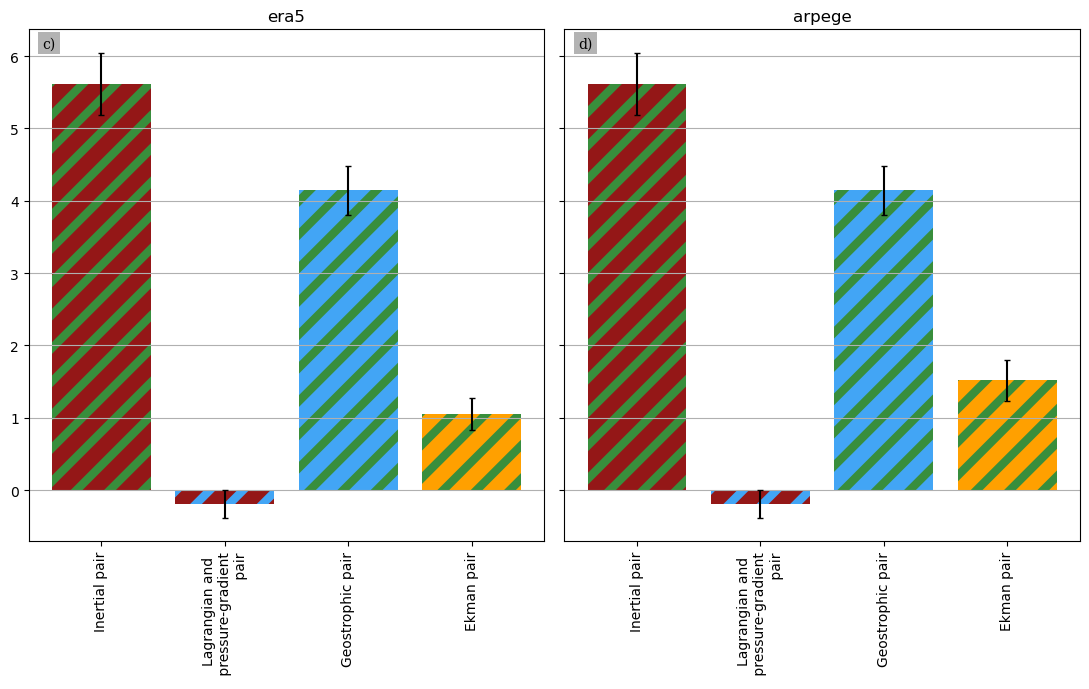

In [33]:
plt.rcParams["axes.edgecolor"] = "k"
plt.rcParams["hatch.linewidth"] = 6
fig, axs = plt.subplots(1, 2, figsize=(11, 7), frameon=False, sharex=True, sharey=True)
axs = axs.flatten()
plot_(df, axs, 0)
for ax in axs:
    ax.grid(axis="y")
    ax.set_xticks(
        [0, 1, 2, 3],
        [
            "Inertial pair",
            "Lagrangian and \n pressure-gradient\n pair",
            "Geostrophic pair",
            "Ekman pair",
        ],
        rotation=90,
        ha="right",
        va="center",
        rotation_mode="anchor",
    )
fig.tight_layout()